In [1]:
import seaborn as sns
import pandas as pd

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [11]:
# Import Dataset
df = pd.read_csv('IPL.csv')
df.head()
df.tail()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22
73,74,"May 29,2022","Narendra Modi Stadium, Ahmedabad",Gujarat,Rajasthan,Final,Rajasthan,Bat,130,9,133,3,Gujarat,Wickets,7,Hardik Pandya,Shubman Gill,45,Hardik Pandya,3--17


In [7]:
df.shape

(74, 20)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [ ]:
df.isnull().sum()
# NUll valuues in particular columns

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [14]:
match_wins = df['match_winner'].value_counts()
# it is a series

Text(0.5, 1.0, 'Most Match Won')

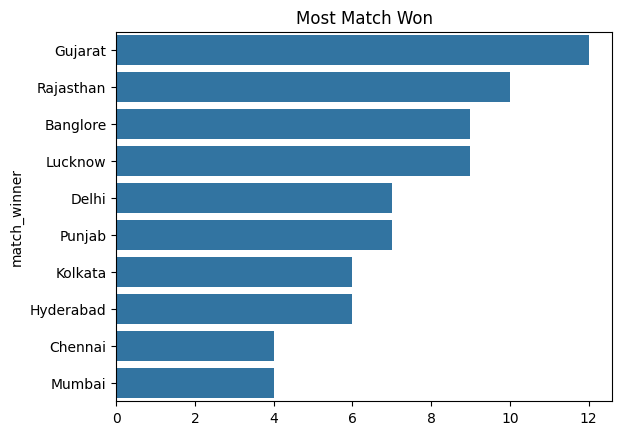

In [18]:
sns.barplot(y=match_wins.index, x = match_wins.values)
plt.title('Most Match Won')

Toss Decision Trends

<Axes: xlabel='toss_decision', ylabel='count'>

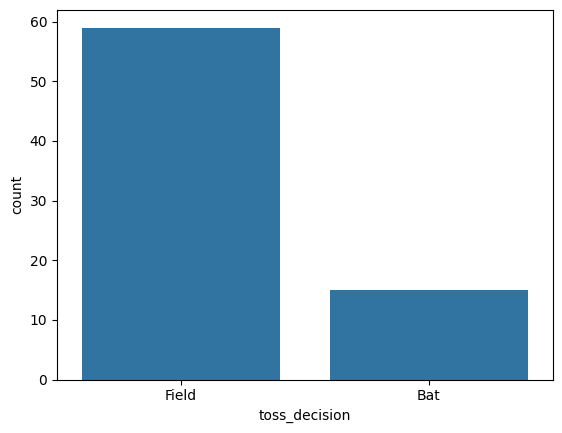

In [19]:
sns.countplot(x=df['toss_decision'])

Are toss winner also match winners

In [24]:
count = df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage = (count*100)/df.shape[0]
percentage

np.float64(48.648648648648646)

How do teams win? Runs vs wicket

<Axes: xlabel='count', ylabel='won_by'>

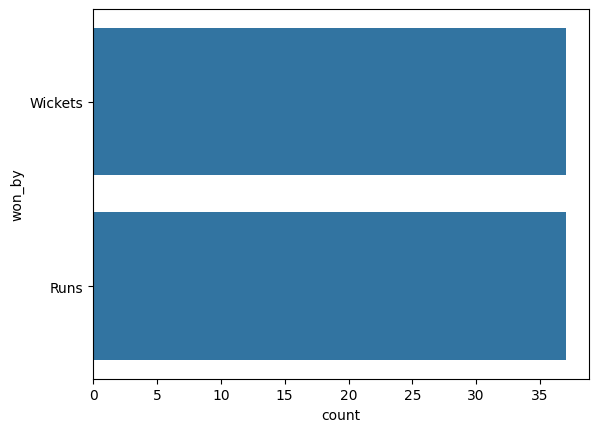

In [25]:
sns.countplot(df['won_by'])

<Axes: ylabel='player_of_the_match'>

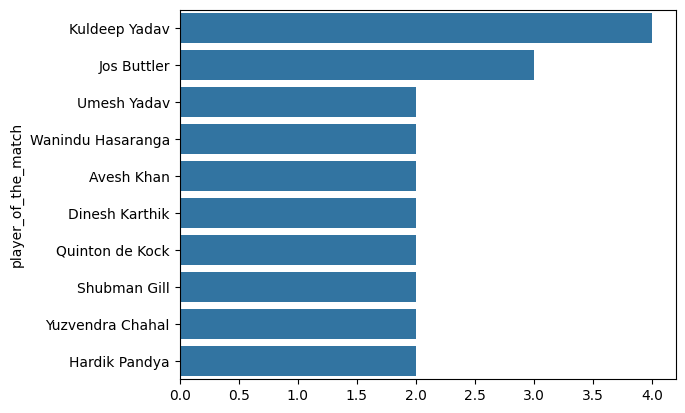

In [30]:
# Most Player of the match 
count = df['player_of_the_match'].value_counts().head(10)
sns.barplot(x=count.values, y=count.index)

In [31]:
# 2 top scoreres
df['top_scorer'].value_counts()

top_scorer
Jos Buttler            7
Quinton de Kock        5
Shubman Gill           4
Liam Livingstone       4
KL Rahul               4
Ishan Kishan           3
Faf du Plessis         3
David Warner           3
W. Saha                3
MS Dhoni               2
Deepak Hooda           2
Andre Russell          2
Abhishek Sharma        2
Shikhar Dhawan         2
Hardik Pandya          2
Rahul Tripathi         2
Virat Kohli            2
Devon Conway           2
Mitchell Marsh         2
Aiden Markram          1
Sherfane Rutherford    1
Pat Cummins            1
Suryakumar Yadav       1
Shimron Hetmyer        1
Kane Williamson        1
Shivam Dube            1
Dinesh Karthik         1
David Miller           1
Tilak Varma            1
Riyan Parag            1
Nitish Rana            1
Ruturaj Gaikwad        1
Sanju Samson           1
Sai Sudharsan          1
Yashasvi Jaiswal       1
Moeen Ali              1
Rajat Patidar          1
Name: count, dtype: int64

<Axes: xlabel='top_scorer'>

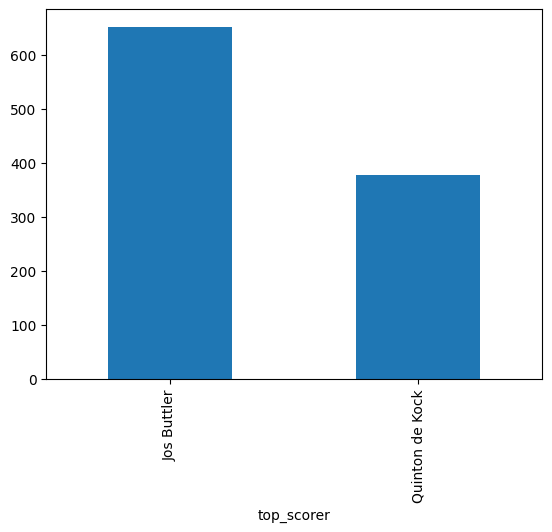

In [43]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high
high.plot(kind = 'bar')

In [ ]:
df[df['top_scorer']=='Jos Buttler']['highscore']

8     100
12     70
29    103
33    116
43     67
70     89
72    106
Name: highscore, dtype: int64

In [50]:
# Highest Wickets
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False)
top_bowlers

best_bowling
Yuzvendra Chahal      17
Jasprit Bumrah        11
Kuldeep Yadav         11
Rashid Khan           11
Josh Hazlewood        10
Kagiso Rabada         10
Avesh Khan            10
Umran Malik            9
Wanindu Hasaranga      9
T Natarajan            8
Maheesh Theekshana     7
Mohsin Khan            7
Lockie Ferguson        7
Andre Russell          7
Daniel Sams            7
Harshal Patel          6
Dwayne Bravo           6
Prasidh Krishna        6
Mohammed Shami         5
Shardul Takur          4
Ravi Bishnoi           4
Hardik Pandya          4
Umesh Yadav            4
Mukesh Choudhary       4
Odean Smith            4
Kuldeep Sen            4
Krunal Pandya          3
Khaleel Ahmed          3
Harpreet Brar          3
Rahul Chahar           3
Ramandeep Singh        3
Moeen Ali              3
Chetan Sakariya        2
Axar Patel             2
Pradeep Sangwan        2
Murugan Ashwin         2
Mohammed Siraj         2
Prashant Solanki       2
Rilley Meredith        2
Tim Southee 

In [52]:
# Most matches by venue
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

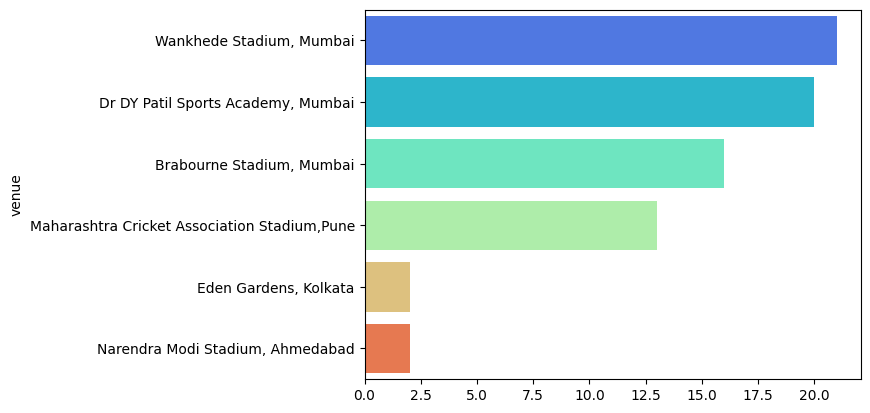

In [53]:
sns.barplot(y=venue_count.index, x=venue_count.values, palette='rainbow')

In [58]:
# Who won by highest margins of runs
df[df['won_by']=='Runs'].sort_values(by='margin', ascending=False).head()[['match_winner','margin']]

,match_winner,margin
54,Chennai,91
52,Lucknow,75
53,Banglore,67
56,Gujarat,62
4,Rajasthan,61


In [61]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [72]:
# Best Bowling Figure - First look out for highest wickets

top_bowlers_hw = df[df['highest_wickets']==df['highest_wickets'].max()]
top_bowler = top_bowlers_hw[top_bowlers_hw['best_bowling_figure'].apply(lambda x: x.split('--')[1]) == top_bowlers_hw['best_bowling_figure'].apply(lambda x: x.split('--')[1]).min()]
top_bowler['best_bowling']

55    Jasprit Bumrah
Name: best_bowling, dtype: str